Loaded CSV columns: ['Epsilon', 'N', 'Eta', 'k', 'Cf_val']
Filtered to n==10; remaining rows: 1008
Detected epsilons: [0.0, 0.1, 0.3, 0.5]
Total samples: 1008
Epoch     1 loss 5.850e+04 field_MSE 1.072e+00 deriv_MSE 1.505e+03 RMSE_unscaled 8.677e+01
Epoch   250 loss 1.534e+02 field_MSE 6.420e-01 deriv_MSE 5.629e+00 RMSE_unscaled 6.716e+01
Epoch   500 loss 1.219e+02 field_MSE 4.984e-01 deriv_MSE 1.511e+00 RMSE_unscaled 5.917e+01
Epoch   750 loss 5.421e+01 field_MSE 3.872e-01 deriv_MSE 3.291e+00 RMSE_unscaled 5.215e+01
Epoch  1000 loss 1.030e+02 field_MSE 3.396e-01 deriv_MSE 2.920e+00 RMSE_unscaled 4.884e+01
Epoch  1250 loss 6.682e+01 field_MSE 3.264e-01 deriv_MSE 2.157e+00 RMSE_unscaled 4.788e+01
Epoch  1500 loss 2.335e+01 field_MSE 3.340e-01 deriv_MSE 1.805e+00 RMSE_unscaled 4.843e+01
Epoch  1750 loss 1.473e+01 field_MSE 3.304e-01 deriv_MSE 6.293e-01 RMSE_unscaled 4.817e+01
Epoch  2000 loss 3.901e+01 field_MSE 3.357e-01 deriv_MSE 4.784e-01 RMSE_unscaled 4.856e+01
Epoch  2250 loss 1.390

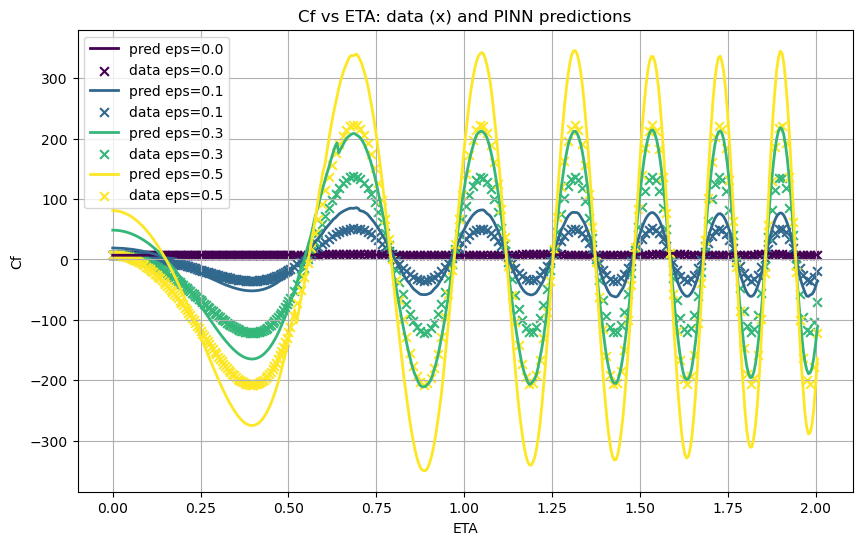

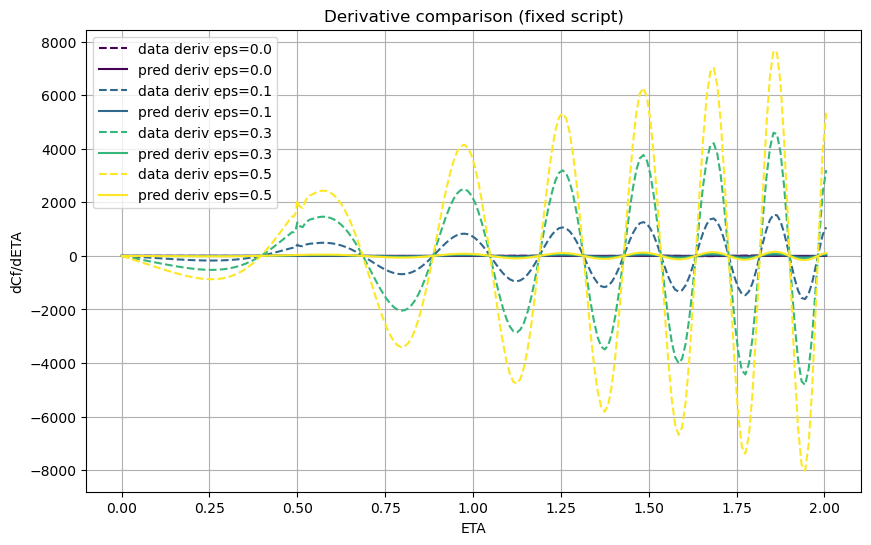

Saved model to pinn_cf_outputs/pinn_cf_model_fixed.pth
Final MSE field (scaled): 0.27422577
Final MSE derivative (scaled): 0.00011189880889161335
Final RMSE Cf (original units): 43.88953056885762


In [1]:
"""
pinn_cf_cf_fixed.py

Corrected PINN training script for Cf(ETA, epsilon) with Sobolev derivative supervision.
Fixes the RuntimeError caused by calling autograd.grad on tensors created under torch.no_grad().
Performs batched diagnostics using create_graph=False to save memory.
"""

import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import OrderedDict
from scipy.signal import savgol_filter
from sklearn.preprocessing import StandardScaler

# Try import torch and give helpful instructions if missing
try:
    import torch
    import torch.nn as nn
    import torch.autograd as autograd
except Exception as e:
    print("PyTorch import failed. For CPU-only install run:")
    print("  pip install --upgrade pip")
    print("  pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu")
    raise

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
np.random.seed(0)

# === User parameters ===
CSV_PATH = "pinn_fg_long_out_4/Cf_long_raw.csv"   # set to your CSV file path
TARGET_N = 10                  # if your CSV has 'n' column filter to n==TARGET_N; otherwise set None
APPLY_SAVGOL = True
SAVGOL_WINDOW = 7
SAVGOL_POLY = 2

# -------------------------
# Robust CSV load & preprocessing (same logic as earlier)
# -------------------------
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"{CSV_PATH} not found in {os.getcwd()}")

df = pd.read_csv(CSV_PATH)
print("Loaded CSV columns:", df.columns.tolist())

col_eta = col_cf = col_eps = col_n = None
for c in df.columns:
    lc = c.strip().lower()
    if 'eta' == lc or 'eta' in lc:
        col_eta = c
    if 'cf' == lc or 'cf' in lc:
        if col_cf is None:
            col_cf = c
    if 'epsilon' == lc or 'eps' in lc:
        col_eps = c
    if lc == 'n':
        col_n = c

if col_eta is None:
    raise RuntimeError("Cannot detect ETA column.")
if col_cf is None:
    raise RuntimeError("Cannot detect Cf column.")
if col_eps is None:
    df['epsilon'] = 0.0
    col_eps = 'epsilon'

# filter by n if present
if col_n is not None:
    df = df[df[col_n] == TARGET_N].copy()
    print(f"Filtered to n=={TARGET_N}; remaining rows: {len(df)}")
else:
    print("No 'n' column; using all rows.")

df = df[[col_eta, col_cf, col_eps]].rename(columns={col_eta: 'ETA', col_cf: 'Cf', col_eps: 'epsilon'})
df = df.dropna().sort_values(['epsilon','ETA']).reset_index(drop=True)

groups = OrderedDict()
for eps, g in df.groupby('epsilon'):
    ETA = g['ETA'].astype(float).values
    Cf = g['Cf'].astype(float).values
    uniq_eta, inv = np.unique(ETA, return_inverse=True)
    Cf_avg = np.array([Cf[inv==i].mean() for i in range(len(uniq_eta))])
    ETA_sorted = uniq_eta
    Cf_sorted = Cf_avg
    if APPLY_SAVGOL and len(Cf_sorted) >= SAVGOL_WINDOW:
        Cf_smooth = savgol_filter(Cf_sorted, window_length=SAVGOL_WINDOW, polyorder=SAVGOL_POLY)
    else:
        Cf_smooth = Cf_sorted.copy()
    N = len(ETA_sorted)
    if N >= 3:
        dCf = np.zeros_like(Cf_smooth)
        for i in range(N):
            if 0 < i < N-1:
                dCf[i] = (Cf_smooth[i+1] - Cf_smooth[i-1]) / (ETA_sorted[i+1] - ETA_sorted[i-1])
            elif i == 0:
                dCf[i] = (Cf_smooth[1] - Cf_smooth[0]) / (ETA_sorted[1] - ETA_sorted[0])
            else:
                dCf[i] = (Cf_smooth[-1] - Cf_smooth[-2]) / (ETA_sorted[-1] - ETA_sorted[-2])
    else:
        dCf = np.gradient(Cf_smooth, ETA_sorted)
    groups[float(eps)] = (ETA_sorted, Cf_sorted, dCf)

print("Detected epsilons:", list(groups.keys()))

X_list = []; Y_list = []; dY_list = []
for eps, (ETA, Cf, dCf) in groups.items():
    for x,y,dy in zip(ETA, Cf, dCf):
        X_list.append([float(x), float(eps)])
        Y_list.append([float(y)])
        dY_list.append([float(dy)])
X = np.array(X_list, dtype=np.float32)
Y = np.array(Y_list, dtype=np.float32)
dY = np.array(dY_list, dtype=np.float32)
print("Total samples:", X.shape[0])

# scaling
scaler_X = StandardScaler().fit(X)
X_scaled = scaler_X.transform(X)
scaler_Y = StandardScaler().fit(Y)
Y_scaled = scaler_Y.transform(Y)

eta_std = scaler_X.scale_[0]
dY_scaled = (dY / scaler_Y.scale_[0]) / eta_std

# Torch tensors
X_t = torch.tensor(X_scaled, dtype=torch.float32, device=device)
Y_t = torch.tensor(Y_scaled, dtype=torch.float32, device=device)
dY_t = torch.tensor(dY_scaled, dtype=torch.float32, device=device)

# -------------------------
# Model: Fourier features + MLP
# -------------------------
class FourierFeatures(nn.Module):
    def __init__(self, in_dim, mapping_size=64, scale=6.0):
        super().__init__()
        B = torch.randn(in_dim, mapping_size) * scale
        self.register_buffer("B", B)
    def forward(self, x):
        xp = 2.0 * math.pi * x @ self.B
        return torch.cat([torch.sin(xp), torch.cos(xp)], dim=-1)

class PINNScalar(nn.Module):
    def __init__(self, in_dim=2, out_dim=1, hidden=200, depth=6, ff_size=64):
        super().__init__()
        self.ff = FourierFeatures(in_dim, mapping_size=ff_size, scale=6.0)
        dims = ff_size * 2
        layers = []
        layers.append(nn.Linear(dims, hidden)); layers.append(nn.Tanh())
        for _ in range(depth-1):
            layers.append(nn.Linear(hidden, hidden)); layers.append(nn.Tanh())
        layers.append(nn.Linear(hidden, out_dim))
        self.net = nn.Sequential(*layers)
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight); nn.init.zeros_(m.bias)
    def forward(self, x):
        x = self.ff(x)
        return self.net(x)

net = PINNScalar(in_dim=2, out_dim=1, hidden=200, depth=6, ff_size=64).to(device)

# derivative helper for training (create_graph=True used in training)
def batch_derivative_for_loss(xb):
    # xb must require grad
    yb = net(xb)
    dy_dxscaled = autograd.grad(outputs=yb, inputs=xb, grad_outputs=torch.ones_like(yb),
                                create_graph=True, retain_graph=True)[0][:, 0:1]
    dy_dETA = dy_dxscaled / eta_std
    return yb, dy_dETA, dy_dxscaled

# Diagnostics evaluation in chunks (create_graph=False to save memory)
def eval_in_chunks(X_scaled_np, chunk_size=2048):
    n = X_scaled_np.shape[0]
    y_all = []
    dy_all = []
    for i0 in range(0, n, chunk_size):
        i1 = min(n, i0 + chunk_size)
        X_chunk = torch.tensor(X_scaled_np[i0:i1], dtype=torch.float32, device=device).requires_grad_(True)
        y_chunk = net(X_chunk)
        # compute derivative for diagnostics with create_graph=False
        dy_dxscaled = autograd.grad(outputs=y_chunk, inputs=X_chunk, grad_outputs=torch.ones_like(y_chunk),
                                    create_graph=False, retain_graph=False)[0][:,0:1]
        dy_dETA = dy_dxscaled / eta_std
        y_all.append(y_chunk.detach().cpu().numpy())
        dy_all.append(dy_dETA.detach().cpu().numpy())
    y_all = np.vstack(y_all)
    dy_all = np.vstack(dy_all)
    return y_all, dy_all

# -------------------------
# Training loop (Adam) with Sobolev loss
# -------------------------
lr = 5e-4
opt = torch.optim.Adam(net.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, 'min', factor=0.5, patience=600, min_lr=1e-7)
w_data = 1.0
w_sob = 30.0
w_jac = 1e-5

batch_size = min(1024, X_t.shape[0])
epochs = 20000
indices = np.arange(X_t.shape[0])

for epoch in range(1, epochs+1):
    perm = np.random.choice(indices, size=batch_size, replace=False)
    xb = X_t[perm].clone().detach().requires_grad_(True)  # requires grad for create_graph
    yb = Y_t[perm]
    dyb = dY_t[perm]

    opt.zero_grad()
    y_pred, dy_pred, dy_dxscaled = batch_derivative_for_loss(xb)
    loss_data = ((y_pred - yb)**2).mean()
    loss_sob = ((dy_pred - dyb)**2).mean()
    jac_reg = (dy_dxscaled**2).mean()
    loss = w_data*loss_data + w_sob*loss_sob + w_jac*jac_reg
    loss.backward()
    torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=5.0)
    opt.step()

    if (epoch % 250 == 0) or (epoch == 1):
        # diagnostics computed without torch.no_grad() but with create_graph=False in eval_in_chunks
        y_all_scaled_np = X_scaled  # numpy array from earlier
        y_all_pred_scaled, dy_all_pred = eval_in_chunks(y_all_scaled_np, chunk_size=2048)
        mse_field = np.mean((y_all_pred_scaled - Y_scaled)**2)
        mse_deriv = np.mean((dy_all_pred - dY_scaled)**2)
        # unscale Cf RMSE
        y_unscaled = scaler_Y.inverse_transform(y_all_pred_scaled)
        rmse_unscaled = math.sqrt(np.mean((y_unscaled - Y)**2))
        print(f"Epoch {epoch:5d} loss {loss.item():.3e} field_MSE {mse_field:.3e} deriv_MSE {mse_deriv:.3e} RMSE_unscaled {rmse_unscaled:.3e}")

    if epoch % 1000 == 0:
        scheduler.step(loss.item())

# Optional L-BFGS refine (keeps create_graph in closure)
print("Running L-BFGS refinement (optional)...")
def closure():
    opt_lbfgs.zero_grad()
    y_all = net(X_t)
    # compute dy for full dataset (may be memory heavy if large)
    X_req = X_t.clone().detach().requires_grad_(True)
    y_req = net(X_req)
    dy_dxscaled_all = autograd.grad(outputs=y_req, inputs=X_req, grad_outputs=torch.ones_like(y_req),
                                    create_graph=True, retain_graph=True)[0][:,0:1]
    dy_dETA_all = dy_dxscaled_all / eta_std
    loss_data_all = ((y_all - Y_t)**2).mean()
    loss_sob_all = ((dy_dETA_all - dY_t)**2).mean()
    loss_total = w_data*loss_data_all + w_sob*loss_sob_all + w_jac*(dy_dxscaled_all**2).mean()
    loss_total.backward()
    return loss_total

opt_lbfgs = torch.optim.LBFGS(net.parameters(), max_iter=300, history_size=50, line_search_fn='strong_wolfe')
opt_lbfgs.step(closure)
print("L-BFGS done.")

# -------------------------
# Final eval & plotting
# -------------------------
os.makedirs("pinn_cf_outputs", exist_ok=True)
# Predictions on fine grids per epsilon
plt.figure(figsize=(10,6))
colors = plt.cm.viridis(np.linspace(0,1,len(groups)))
for i,(eps,(ETA, Cf, dCf)) in enumerate(groups.items()):
    ETA_fine = np.linspace(np.min(ETA), np.max(ETA), 400)
    Xfine = np.vstack([ETA_fine, np.full_like(ETA_fine, float(eps))]).T
    Xfine_scaled = scaler_X.transform(Xfine)
    Xfine_t = torch.tensor(Xfine_scaled, dtype=torch.float32, device=device)
    with torch.no_grad():
        y_pred_scaled = net(Xfine_t).cpu().numpy()
    y_pred = scaler_Y.inverse_transform(y_pred_scaled).ravel()
    plt.plot(ETA_fine, y_pred, color=colors[i], label=f"pred eps={eps}", linewidth=2)
    plt.scatter(ETA, Cf, color=colors[i], marker='x', s=40, label=f"data eps={eps}")
plt.xlabel("ETA"); plt.ylabel("Cf"); plt.legend(); plt.grid(True)
plt.title("Cf vs ETA: data (x) and PINN predictions")
plt.savefig("pinn_cf_outputs/cf_vs_eta_predictions_fixed.png", dpi=200)
plt.show()

# derivative comparison at data ETA points (diagnostics)
plt.figure(figsize=(10,6))
for i,(eps,(ETA, Cf, dCf)) in enumerate(groups.items()):
    Xpts = np.vstack([ETA, np.full_like(ETA, float(eps))]).T
    Xpts_scaled = scaler_X.transform(Xpts)
    # compute in chunks or single chunk depending on size
    Xpts_t = torch.tensor(Xpts_scaled, dtype=torch.float32, device=device).requires_grad_(True)
    y_pred = net(Xpts_t)
    dy_dxscaled = autograd.grad(outputs=y_pred, inputs=Xpts_t, grad_outputs=torch.ones_like(y_pred),
                                create_graph=False, retain_graph=False)[0][:,0:1]
    dy_dETA_pred = (dy_dxscaled / eta_std).cpu().numpy().ravel()
    plt.plot(ETA, dCf, color=colors[i], linestyle='--', label=f"data deriv eps={eps}")
    plt.plot(ETA, dy_dETA_pred, color=colors[i], linestyle='-', label=f"pred deriv eps={eps}")
plt.xlabel("ETA"); plt.ylabel("dCf/dETA"); plt.legend(); plt.grid(True)
plt.title("Derivative comparison (fixed script)")
plt.savefig("pinn_cf_outputs/dCf_dEta_comparison_fixed.png", dpi=200)
plt.show()

# Save model + scalers
torch.save({
    'state_dict': net.state_dict(),
    'scaler_X_mean': scaler_X.mean_,
    'scaler_X_scale': scaler_X.scale_,
    'scaler_Y_mean': scaler_Y.mean_,
    'scaler_Y_scale': scaler_Y.scale_
}, "pinn_cf_outputs/pinn_cf_model_fixed.pth")
print("Saved model to pinn_cf_outputs/pinn_cf_model_fixed.pth")

# numeric summary final
y_all_scaled_np = X_scaled
y_all_pred_scaled, dy_all_pred = eval_in_chunks(y_all_scaled_np, chunk_size=2048)
mse_field = np.mean((y_all_pred_scaled - Y_scaled)**2)
mse_deriv = np.mean((dy_all_pred - dY_scaled)**2)
y_unscaled = scaler_Y.inverse_transform(y_all_pred_scaled)
rmse_unscaled = math.sqrt(np.mean((y_unscaled - Y)**2))
print("Final MSE field (scaled):", mse_field)
print("Final MSE derivative (scaled):", mse_deriv)
print("Final RMSE Cf (original units):", rmse_unscaled)

# End of script
